In [86]:
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

import sys 
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve() / 'modules'))

from data_loading import (
    load_competition_data,
    load_football_data_odds,
    merge_odds_with_matches,
)


INPUT_DIR  = Path('..') / '..' / 'data' / 'input_data'
ODDS_DIR   = Path('..') / '..' / 'data' / 'odds'

In [40]:
dict_dfs = {
    'GER': pd.read_parquet('../../data/input_data/bundesliga_1516.parquet'),
    'ENG': pd.read_parquet('../../data/input_data/epl_1516.parquet'),
    'ESP': pd.read_parquet('../../data/input_data/laliga_1516.parquet'),
    'ITA': pd.read_parquet('../../data/input_data/seriea_1516.parquet'),
    'FRA': pd.read_parquet('../../data/input_data/ligue1_1516.parquet')
}

df_all = pd.concat(dict_dfs.values(), ignore_index=True)

In [41]:
LEAGUES = [
    {'slug': 'epl_1516',        'odds_code': 'E0',  'comp_name': 'England - Premier League'},
    {'slug': 'bundesliga_1516', 'odds_code': 'D1',  'comp_name': 'Germany - 1. Bundesliga'},
    {'slug': 'laliga_1516',     'odds_code': 'SP1', 'comp_name': 'Spain - La Liga'},
    {'slug': 'seriea_1516',     'odds_code': 'I1',  'comp_name': 'Italy - Serie A'},
    {'slug': 'ligue1_1516',     'odds_code': 'F1',  'comp_name': 'France - Ligue 1'},
]


In [116]:
dict_dfs = {}
ls_home_shots = []
ls_away_shots = []
ls_home_xg = []
ls_away_xg = []

ls_home_total_xg = []
ls_away_total_xg = []
ls_home_goals = []
ls_away_goals = []

for cfg in tqdm(LEAGUES, total=len(LEAGUES), desc='Leagues'):
    slug = cfg['slug']
    print(f'\n=== {slug} ===')

    # 1) Load and merge betting odds; retain only complete records
    data = load_competition_data(INPUT_DIR / f'{slug}.parquet')
    odds = load_football_data_odds(ODDS_DIR / f"{cfg['odds_code']}.csv",
                                   competition_name=cfg['comp_name'],
                                   date_format='%Y-%m-%d')
    data = merge_odds_with_matches(data, odds)
    data = data[data['betting_p_home'].notna()].reset_index(drop=True)
    print(f'  Using {len(data)} complete records.')
    dict_dfs[slug] = data
    ls_home_shots.append(data['home_shots'].to_list())
    ls_away_shots.append(data['away_shots'].to_list())
    ls_home_xg.append(data['home_xg_values'].to_list())
    ls_away_xg.append(data['away_xg_values'].to_list())
    ls_home_total_xg.append(data['home_xg'].to_list())
    ls_away_total_xg.append(data['away_xg'].to_list())
    ls_home_goals.append(data['home_goals'].to_list())
    ls_away_goals.append(data['away_goals'].to_list())

ls_home_shots = [x for xs in ls_home_shots for x in xs]
ls_away_shots = [x for xs in ls_away_shots for x in xs]

ls_home_total_xg = [x for xs in ls_home_total_xg for x in xs]
ls_away_total_xg = [x for xs in ls_away_total_xg for x in xs]

ls_home_goals = [x for xs in ls_home_goals for x in xs]
ls_away_goals = [x for xs in ls_away_goals for x in xs]

ls_home_xg_temp = [x for xs in ls_home_xg for x in xs if x is not None]
ls_away_xg_temp = [x for xs in ls_away_xg for x in xs if x is not None]
ls_home_xg = [x for xs in ls_home_xg_temp for x in xs]
ls_away_xg = [x for xs in ls_away_xg_temp for x in xs]


Leagues:   0%|          | 0/5 [00:00<?, ?it/s]


=== epl_1516 ===
Betting odds matched for 380/380 matches.
  Using 380 complete records.

=== bundesliga_1516 ===
Betting odds matched for 306/306 matches.
  Using 306 complete records.

=== laliga_1516 ===
Betting odds matched for 380/380 matches.
  Using 380 complete records.

=== seriea_1516 ===
Betting odds matched for 380/380 matches.
  Using 380 complete records.

=== ligue1_1516 ===
Betting odds matched for 376/377 matches.
  Using 376 complete records.


## Number of Shots

In [103]:
print(f'Total Number of Shots: {np.sum(ls_home_shots) + np.sum(ls_away_shots)}')
print(f'Total Number of Shots for Home Team: {np.sum(ls_home_shots)}')
print(f'Total Number of Shots for Away Team: {np.sum(ls_away_shots)}')

print(f'Average Number of Shots for Home Team: {np.mean(ls_home_shots):.2f} (SD={np.std(ls_home_shots):.2f})')
print(f'Average Number of Shots for Away Team: {np.mean(ls_away_shots):.2f} (SD={np.std(ls_away_shots):.2f})')

Total Number of Shots: 45705
Total Number of Shots for Home Team: 25298
Total Number of Shots for Away Team: 20407
Average Number of Shots for Home Team: 13.88 (SD=5.27)
Average Number of Shots for Away Team: 11.20 (SD=4.49)


<Axes: ylabel='Count'>

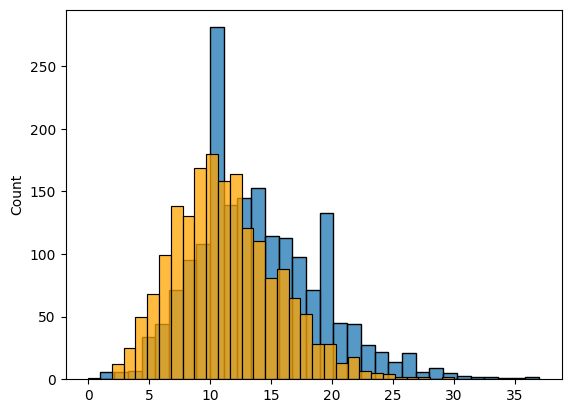

In [105]:
sns.histplot(ls_home_shots)
sns.histplot(ls_away_shots, color='orange')

## xG Values Descriptives

In [115]:
np.sum(ls_home_xg), np.sum(ls_away_xg)

(np.float64(2570.4882940903), np.float64(2005.8959859366998))

<Axes: ylabel='Count'>

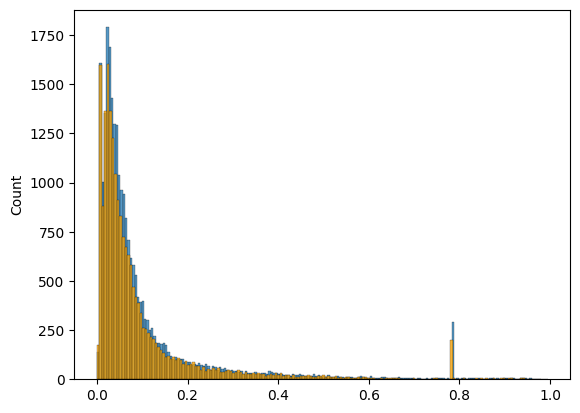

In [110]:
sns.histplot(ls_home_xg)
sns.histplot(ls_away_xg, color='orange')

In [114]:
print(f'Mean xG for Home Team: {np.mean(ls_home_xg):.2f}, SD={np.std(ls_home_xg):.2f}')
print(f'Mean xG for Away Team: {np.mean(ls_away_xg):.2f}, SD={np.std(ls_away_xg):.2f}')

print(f'Median xG for Home Team: {np.median(ls_home_xg):.2f}, IQR={np.percentile(ls_home_xg, 75) - np.percentile(ls_home_xg, 25):.2f}')
print(f'Median xG for Away Team: {np.median(ls_away_xg):.2f}, IQR={np.percentile(ls_away_xg, 75) - np.percentile(ls_away_xg, 25):.2f}')

Mean xG for Home Team: 0.10, SD=0.14
Mean xG for Away Team: 0.10, SD=0.14
Median xG for Home Team: 0.05, IQR=0.08
Median xG for Away Team: 0.05, IQR=0.08


In [71]:
# descriptive statistics for shots and xg

print(f'Shots: mean={np.mean(ls_shots):.2f}, median={np.median(ls_shots):.2f}, std={np.std(ls_shots):.2f}, min={np.min(ls_shots)}, max={np.max(ls_shots)}')
print(f'xg: mean={np.mean(ls_xg):.2f}, median={np.median(ls_xg):.2f}, std={np.std(ls_xg):.2f}, min={np.min(ls_xg)}, max={np.max(ls_xg)}')

# IQR
q1_shots = np.percentile(ls_shots, 25)
q3_shots = np.percentile(ls_shots, 75)
iqr_shots = q3_shots - q1_shots
print(f'Shots: Q1={q1_shots}, Q3={q3_shots}, IQR={iqr_shots}')
q1_xg = np.percentile(ls_xg, 25)
q3_xg = np.percentile(ls_xg, 75)
iqr_xg = q3_xg - q1_xg
print(f'xg: Q1={q1_xg:.2f}, Q3={q3_xg:.2f}, IQR={iqr_xg:.2f}')

Shots: mean=12.54, median=12.00, std=5.07, min=0, max=37
xg: mean=0.10, median=0.05, std=0.14, min=0.00018, max=0.9951224
Shots: Q1=9.0, Q3=16.0, IQR=7.0
xg: Q1=0.03, Q3=0.10, IQR=0.08


In [72]:
print(f'Proportion of shots > 10: {len([x for x in ls_shots if x > 10]) / len(ls_shots):.2%}')
print(f'Proportion of xg > 0.3: {len([x for x in ls_xg if x > 0.3]) / len(ls_xg):.2%}')
print(f'Proportion of xg < 0.05: {len([x for x in ls_xg if x < 0.05]) / len(ls_xg):.2%}')

Proportion of shots > 10: 62.05%
Proportion of xg > 0.3: 7.36%
Proportion of xg < 0.05: 49.08%


In [85]:
print(f'Mean Home XG: {np.mean(ls_home_xg):.2f}, SD={np.std(ls_home_xg):.2f}')
print(f'Mean Away XG: {np.mean(ls_away_xg):.2f}, SD={np.std(ls_away_xg):.2f}')

Mean Home XG: 1.41, SD=0.81
Mean Away XG: 1.10, SD=0.69


<Axes: ylabel='Count'>

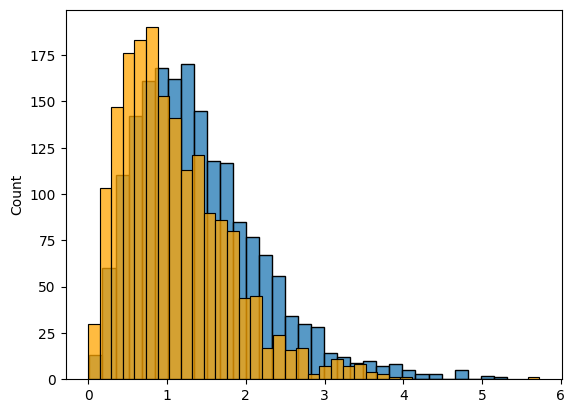

In [83]:
sns.histplot(ls_home_xg)
sns.histplot(ls_away_xg, color='orange')

## Actual Goal Numbers

In [120]:
print(f'Total Number of Home Goals: {np.sum(ls_home_goals):.2f}')
print(f'Total Number of Away Goals: {np.sum(ls_away_goals):.2f}')

print(f'Mean Number of Home Goals: {np.mean(ls_home_goals):.2f}')
print(f'Mean Number of Away Goals: {np.mean(ls_away_goals):.2f}')

Total Number of Home Goals: 2762.00
Total Number of Away Goals: 2099.00
Mean Number of Home Goals: 1.52
Mean Number of Away Goals: 1.15
